# 🏁 Karting Championship – Full Statistical Analysis
### Professional Competition Ranking Model

Este notebook incluye:
- Extracción y limpieza de datos desde Google Sheets
- Asignación de trazado por fecha
- Imputación bidireccional por regresión (A↔B↔C)
- Métricas generales y por trazado
- Seis metodologías de ranking independientes
- Ranking por consenso robusto (mediana)
- Performance Index Pro (0–100)
- Análisis de sensibilidad
- Visualizaciones completas

## 1️⃣ Imports

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import gspread
from google.oauth2.service_account import Credentials
import warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_dark"
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2️⃣ Conexión a Google Sheets

In [50]:
scope = ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive']
creds = Credentials.from_service_account_file('credentials.json', scopes=scope)
client = gspread.authorize(creds)

spreadsheet = client.open('Mundial de Karting 2026')  # ← cambiar
worksheet = spreadsheet.worksheet('Tiempos 2026')   # ← cambiar

## 3️⃣ Extracción y Procesamiento

In [51]:
data = worksheet.get_all_values()
raw = pd.DataFrame(data)

# Estructura de filas
semanas_row = raw.iloc[0]     # fila 0: S51, S52...
fechas_row  = raw.iloc[1]     # fila 1: 04/01/2026, 11/01/2026...
headers     = raw.iloc[2]     # fila 2: N, Pilotos, Mejor Tiempo...

df = raw.iloc[3:].copy()
df.columns = headers.str.strip()

# Renombrar columnas carrera con índice único para evitar colisiones
fechas_filled = pd.Series(fechas_row.values).replace('', pd.NA).ffill()

new_cols = []
for i, col in enumerate(df.columns):
    if 'Carrera' in str(col):
        new_cols.append(f"{col}__idx{i}")
    else:
        new_cols.append(col)
df.columns = new_cols

race_cols = [col for col in df.columns if 'Carrera' in col]

# Mapeo columna → fecha
col_to_fecha = {}
for col in race_cols:
    i = int(col.split('__idx')[1])
    col_to_fecha[col] = fechas_filled.iloc[i]

print(f'✅ Columnas carrera encontradas: {len(race_cols)}')
print(f'✅ Muestra mapeo: {list(col_to_fecha.items())[:4]}')

✅ Columnas carrera encontradas: 104
✅ Muestra mapeo: [('Carrera 1__idx5', '04/01/2026'), ('Carrera 2__idx6', '04/01/2026'), ('Carrera 1__idx7', '11/01/2026'), ('Carrera 2__idx8', '11/01/2026')]


## 4️⃣ Asignación de Trazado

In [52]:
def asignar_trazado(fecha):
    try:
        fecha = pd.to_datetime(fecha, dayfirst=True)
    except Exception:
        return None
    # ── AJUSTA ESTAS FECHAS SEGÚN TU CAMPEONATO ──────────────────
    if fecha == pd.Timestamp('2026-01-25'):
        return 'B'
    if fecha < pd.Timestamp('2026-02-22'):
        return 'A'
    else:
        return 'C'
    # ─────────────────────────────────────────────────────────────

# Melt a formato largo
df_long = df.melt(
    id_vars=['Pilotos'],
    value_vars=race_cols,
    var_name='Columna',
    value_name='Tiempo'
)
df_long['Tiempo'] = pd.to_numeric(df_long['Tiempo'], errors='coerce')
df_long = df_long.dropna(subset=['Tiempo'])
df_long['Fecha']   = df_long['Columna'].map(col_to_fecha)
df_long['Carrera'] = df_long['Columna'].apply(lambda x: x.split('__idx')[0])
df_long['Trazado'] = df_long['Fecha'].apply(asignar_trazado)
df_long = df_long.dropna(subset=['Trazado'])
df_long = df_long[df_long['Pilotos'].apply(lambda x: len(str(x)) > 1)]

print(df_long['Trazado'].value_counts())
df_long.head()

Trazado
A    95
C    41
B    15
Name: count, dtype: int64


,Pilotos,Columna,Tiempo,Fecha,Carrera,Trazado
0,NICO E,Carrera 1__idx5,39.136,04/01/2026,Carrera 1,A
1,ADOLFO,Carrera 1__idx5,38.841,04/01/2026,Carrera 1,A
3,PAJARITO,Carrera 1__idx5,39.525,04/01/2026,Carrera 1,A
6,JAVIER V,Carrera 1__idx5,39.492,04/01/2026,Carrera 1,A
9,DIEGO EG,Carrera 1__idx5,39.927,04/01/2026,Carrera 1,A


## 5️⃣ Métricas por Trazado y Generales

In [53]:
# ── Por trazado ───────────────────────────────────────────────────
by_trazado = df_long.groupby(['Pilotos', 'Trazado'])['Tiempo'].agg(
    median='median',
    mean='mean',
    std='std',
    best='min',
    sessions='count'
).reset_index()

metrics = by_trazado.pivot(index='Pilotos', columns='Trazado', values=['median','mean','std','best','sessions'])
metrics.columns = [f'{stat}_{traz}' for stat, traz in metrics.columns]
metrics = metrics.reset_index()

# ── Generales ─────────────────────────────────────────────────────
general = df_long.groupby('Pilotos')['Tiempo'].agg(
    overall_median='median',
    overall_mean='mean',
    overall_best='min',
    overall_std='std',
    total_sessions='count'
).reset_index()

metrics = metrics

# ── Generales (todos los trazados) ────────────────────────────────
general = df_long.groupby('Pilotos')['Tiempo'].agg(
    overall_median='median',
    overall_mean='mean',
    overall_best='min',
    overall_std='std',
    total_sessions='count'
).reset_index()

metrics = metrics.merge(general, on='Pilotos', how='left')

# ── Std dentro de cada trazado (consistencia real) ────────────────  ← AGREGAR AQUÍ
std_por_trazado = df_long.groupby(['Pilotos', 'Trazado'])['Tiempo'].std().reset_index()
std_promedio = std_por_trazado.groupby('Pilotos')['Tiempo'].mean().reset_index()
std_promedio.columns = ['Pilotos', 'std_within_track']
metrics = metrics.merge(std_promedio, on='Pilotos', how='left')

## 6️⃣ Correlación entre Trazados

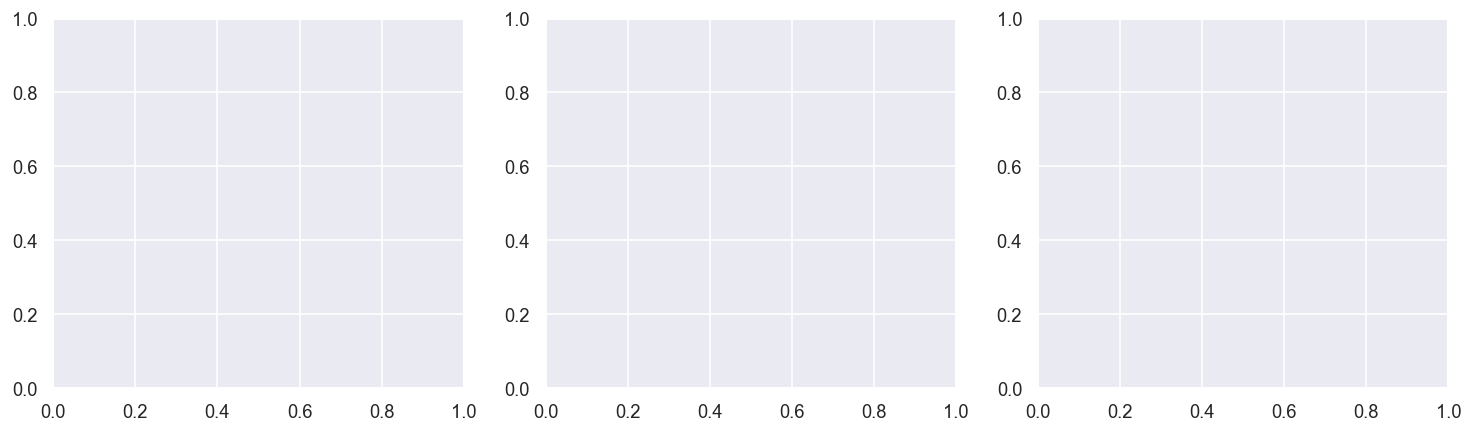

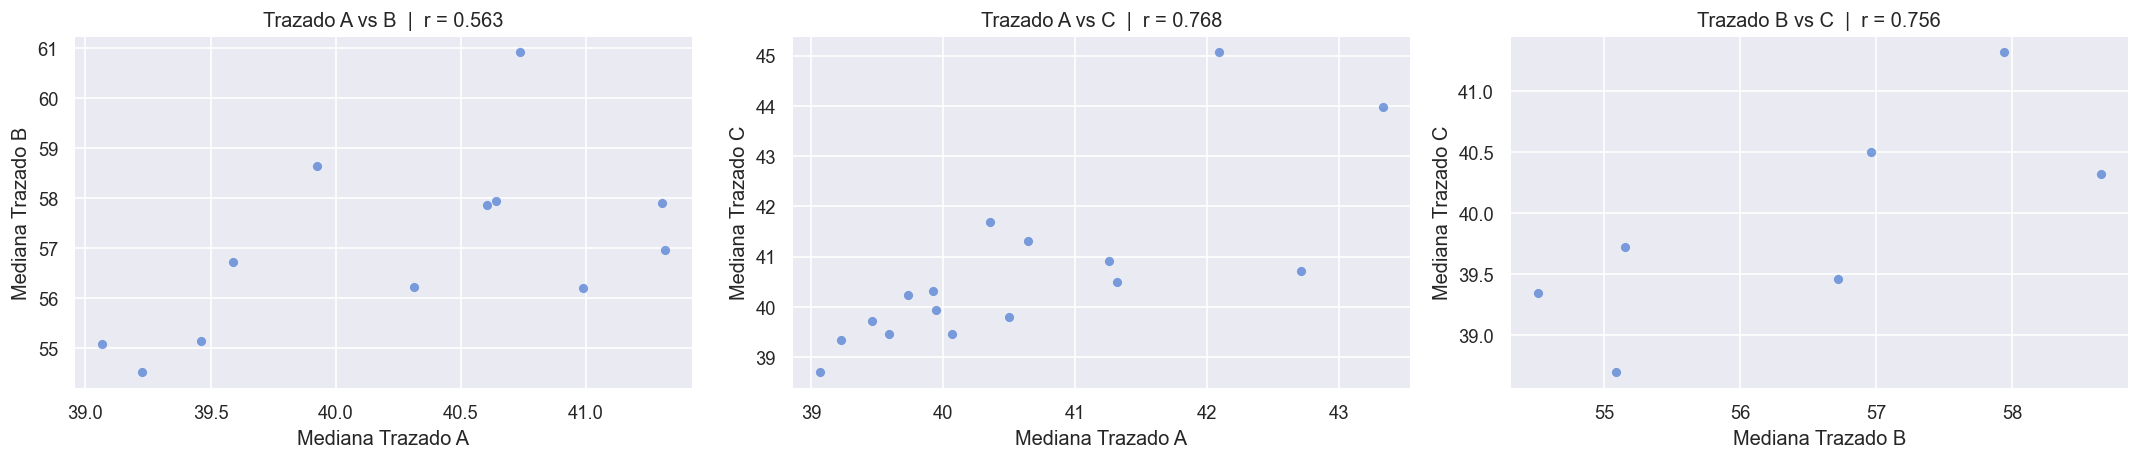


Correlación entre trazados:
          median_A  median_B  median_C
median_A     1.000     0.563     0.768
median_B     0.563     1.000     0.756
median_C     0.768     0.756     1.000


In [54]:
trazados_disponibles = [t for t in ['A', 'B', 'C'] if f'median_{t}' in metrics.columns]
corr_cols = [f'median_{t}' for t in trazados_disponibles]

fig, axes = plt.subplots(1, len(trazados_disponibles), figsize=(5 * len(trazados_disponibles), 4))
if len(trazados_disponibles) == 1:
    axes = [axes]

pairs = [(trazados_disponibles[i], trazados_disponibles[j])
         for i in range(len(trazados_disponibles))
         for j in range(i+1, len(trazados_disponibles))]

fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 4))
if len(pairs) == 1:
    axes = [axes]

for ax, (t1, t2) in zip(axes, pairs):
    sub = metrics[[f'median_{t1}', f'median_{t2}']].dropna()
    ax.scatter(sub[f'median_{t1}'], sub[f'median_{t2}'], alpha=0.7, edgecolors='white', linewidth=0.5)
    corr_val = sub[f'median_{t1}'].corr(sub[f'median_{t2}'])
    ax.set_xlabel(f'Mediana Trazado {t1}')
    ax.set_ylabel(f'Mediana Trazado {t2}')
    ax.set_title(f'Trazado {t1} vs {t2}  |  r = {corr_val:.3f}')

plt.tight_layout()
plt.show()

print('\nCorrelación entre trazados:')
print(metrics[corr_cols].corr().round(3))

## 7️⃣ Imputación Bidireccional por Regresión

In [55]:
metrics['imputed_A'] = False
metrics['imputed_B'] = False
metrics['imputed_C'] = False

def impute_bidirectional(df, col_target, col_predictor, flag_col, min_samples=4):
    """Imputa col_target usando col_predictor. Si hay suficientes datos, ajusta regresión."""
    mask_both = df[col_target].notna() & df[col_predictor].notna()
    missing_target = df[col_target].isna() & df[col_predictor].notna()

    if mask_both.sum() >= min_samples and missing_target.sum() > 0:
        model = LinearRegression()
        model.fit(df.loc[mask_both, [col_predictor]], df.loc[mask_both, col_target])
        df.loc[missing_target, col_target] = model.predict(df.loc[missing_target, [col_predictor]])
        df.loc[missing_target, flag_col] = True
        print(f'  ↳ {missing_target.sum()} pilotos imputados en {col_target} usando {col_predictor}')
    return df

print('🔁 Imputación bidireccional A ↔ B:')
metrics = impute_bidirectional(metrics, 'median_A', 'median_B', 'imputed_A')
metrics = impute_bidirectional(metrics, 'median_B', 'median_A', 'imputed_B')

print('🔁 Imputación bidireccional A ↔ C:')
metrics = impute_bidirectional(metrics, 'median_A', 'median_C', 'imputed_A')
metrics = impute_bidirectional(metrics, 'median_C', 'median_A', 'imputed_C')

print('🔁 Imputación bidireccional B ↔ C:')
metrics = impute_bidirectional(metrics, 'median_B', 'median_C', 'imputed_B')
metrics = impute_bidirectional(metrics, 'median_C', 'median_B', 'imputed_C')

# Resumen de imputaciones
print(f"\n📊 Resumen:")
print(f"  Pilotos con median_A imputada: {metrics['imputed_A'].sum()}")
print(f"  Pilotos con median_B imputada: {metrics['imputed_B'].sum()}")
print(f"  Pilotos con median_C imputada: {metrics['imputed_C'].sum()}")

🔁 Imputación bidireccional A ↔ B:
  ↳ 3 pilotos imputados en median_A usando median_B
  ↳ 18 pilotos imputados en median_B usando median_A
🔁 Imputación bidireccional A ↔ C:
  ↳ 8 pilotos imputados en median_A usando median_C
  ↳ 17 pilotos imputados en median_C usando median_A
🔁 Imputación bidireccional B ↔ C:
  ↳ 8 pilotos imputados en median_B usando median_C

📊 Resumen:
  Pilotos con median_A imputada: 11
  Pilotos con median_B imputada: 26
  Pilotos con median_C imputada: 17


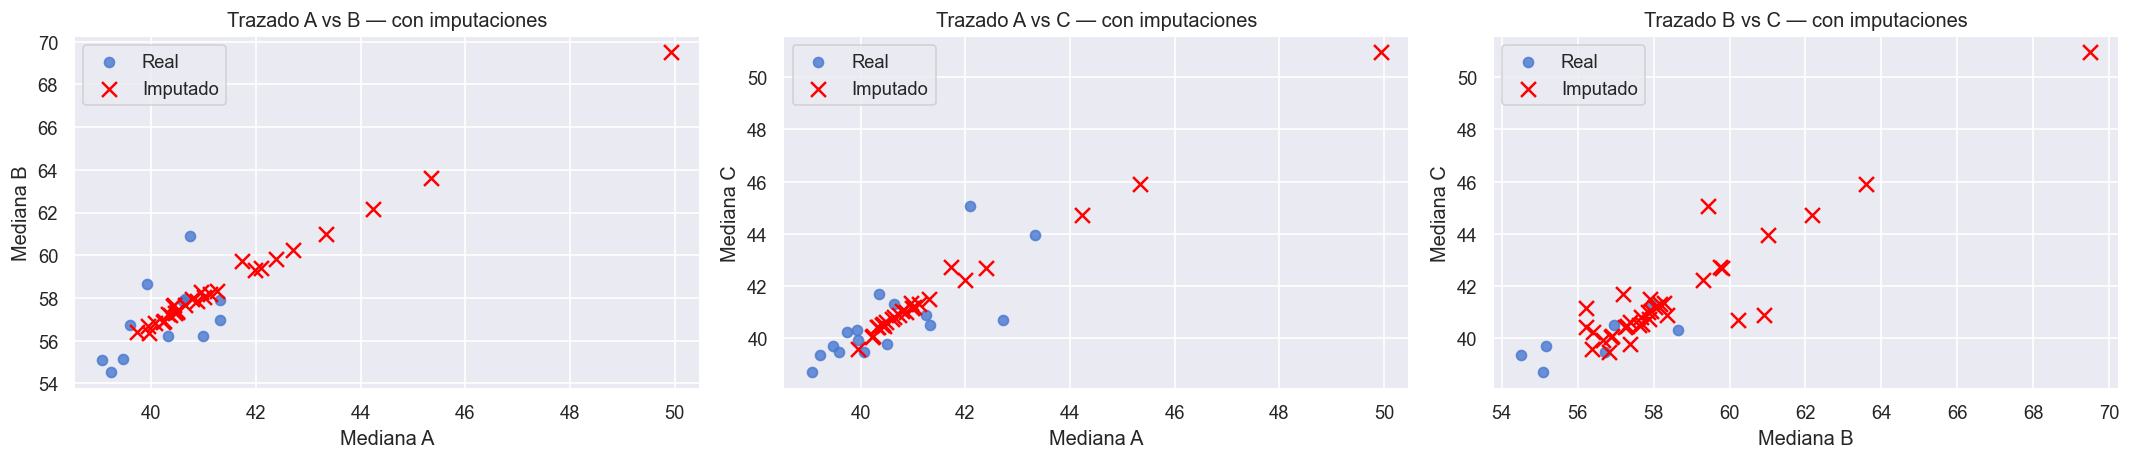

In [56]:
# Visualizar imputaciones
fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 4))
if len(pairs) == 1:
    axes = [axes]

for ax, (t1, t2) in zip(axes, pairs):
    imputed_mask = metrics[f'imputed_{t1}'] | metrics[f'imputed_{t2}']
    real = metrics[~imputed_mask]
    imp  = metrics[imputed_mask]
    sub_real = real[[f'median_{t1}', f'median_{t2}']].dropna()
    sub_imp  = imp[[f'median_{t1}',  f'median_{t2}']].dropna()
    ax.scatter(sub_real[f'median_{t1}'], sub_real[f'median_{t2}'], label='Real', alpha=0.8)
    if len(sub_imp) > 0:
        ax.scatter(sub_imp[f'median_{t1}'],  sub_imp[f'median_{t2}'],  label='Imputado', marker='x', s=80, color='red')
    ax.set_xlabel(f'Mediana {t1}')
    ax.set_ylabel(f'Mediana {t2}')
    ax.set_title(f'Trazado {t1} vs {t2} — con imputaciones')
    ax.legend()

plt.tight_layout()
plt.show()

## 8️⃣ Seis Metodologías de Ranking

In [57]:
def build_ranking(series, name, ascending=True):
    """Crea ranking a partir de una serie numérica."""
    r = pd.DataFrame({'Pilotos': metrics['Pilotos'], 'metric': series})
    r = r.dropna(subset=['metric']).sort_values('metric', ascending=ascending).reset_index(drop=True)
    r['place'] = range(1, len(r) + 1)
    r['method'] = name
    return r

# Determinar pesos dinámicamente según trazados con datos
has_A = metrics['median_A'].notna().sum() > 3
has_B = metrics['median_B'].notna().sum() > 3
has_C = metrics['median_C'].notna().sum() > 3

# 1. Promedio simple de medianas disponibles
available = [c for c, h in [('median_A', has_A), ('median_B', has_B), ('median_C', has_C)] if h]
r1 = build_ranking(metrics[available].mean(axis=1), 'Promedio Simple')

# 2. Ponderado: A tiene más peso (más sesiones)
weighted = pd.Series(0.0, index=metrics.index)
total_w = 0
if has_A: weighted += 0.5 * metrics['median_A'].fillna(0); total_w += 0.5
if has_B: weighted += 0.2 * metrics['median_B'].fillna(0); total_w += 0.2
if has_C: weighted += 0.3 * metrics['median_C'].fillna(0); total_w += 0.3
r2 = build_ranking(weighted / total_w, 'Ponderado A>C>B')

# 3. Z-Score normalizado por trazado
z_total = pd.Series(0.0, index=metrics.index)
z_count = 0
for col in available:
    z = (metrics[col] - metrics[col].mean()) / metrics[col].std()
    z_total += z.fillna(0)
    z_count += 1
r3 = build_ranking(z_total / z_count, 'Z-Score')

# 4. Percentil (rank relativo dentro de cada trazado, promediado)
pct_total = pd.Series(0.0, index=metrics.index)
for col in available:
    pct_total += metrics[col].rank(pct=True)
r4 = build_ranking(pct_total / len(available), 'Percentil')

# 5. Mejor tiempo normalizado por trazado
best_z = pd.Series(0.0, index=metrics.index)
best_count = 0
for col in [f'best_{t}' for t in trazados_disponibles]:
    if col in metrics.columns:
        z = (metrics[col] - metrics[col].mean()) / metrics[col].std()
        best_z += z.fillna(0)
        best_count += 1
r5 = build_ranking(best_z / best_count, 'Mejor Tiempo Normalizado')

# 6. Consistencia + velocidad: penalizar desviación estándar
consistency_score = metrics['overall_median'] + 0.5 * metrics['std_within_track'].fillna(metrics['std_within_track'].median())
r6 = build_ranking(consistency_score, 'Velocidad + Consistencia')

print('✅ Seis rankings generados')
for r in [r1, r2, r3, r4, r5, r6]:
    print(f"  {r['method'].iloc[0]}: {len(r)} pilotos rankeados")

✅ Seis rankings generados
  Promedio Simple: 41 pilotos rankeados
  Ponderado A>C>B: 41 pilotos rankeados
  Z-Score: 41 pilotos rankeados
  Percentil: 41 pilotos rankeados
  Mejor Tiempo Normalizado: 41 pilotos rankeados
  Velocidad + Consistencia: 41 pilotos rankeados


## 9️⃣ Ranking Consenso Robusto (Mediana)

In [58]:
all_rankings = pd.concat([r1, r2, r3, r4, r5, r6], ignore_index=True)

robust = (
    all_rankings.groupby('Pilotos')['place']
    .agg(median_place='median', std_place='std', n_methods='count')
    .sort_values('median_place')
    .reset_index()
)
robust['final_place'] = range(1, len(robust) + 1)

print(robust.head(15).to_string(index=False))

    Pilotos  median_place  std_place  n_methods  final_place
     NICO E           1.0   0.000000          6            1
     ADOLFO           2.0   0.000000          6            2
   JAVIER V           3.0   0.408248          6            3
   PAJARITO           4.0   0.408248          6            4
   CONSUELO           5.0   2.041241          6            5
   ILYAN30F           6.5   0.816497          6            6
       CRIS           6.5   0.816497          6            7
      WIDOW           8.0   1.602082          6            8
JUAN CAMPOS           9.0   1.602082          6            9
   CLEMENTE          10.0   1.760682          6           10
     SIKEZE          11.0   2.000000          6           11
     JAVIER          12.0   2.316607          6           12
  VICENTE S          13.0  10.703582          6           13
  IGNACIO R          14.0   3.209361          6           14
       MIKE          15.5   1.861899          6           15


In [123]:
robust

,Pilotos,median_place,std_place,n_methods,final_place,Performance_Index,imputed_A,imputed_B,imputed_C,total_sessions,any_imputed
0,NICO E,1.0,0.000000,6,1,100.0,False,False,False,12,False
1,ADOLFO,2.0,0.000000,6,2,97.5,False,False,False,14,False
2,JAVIER V,3.0,0.408248,6,3,95.0,False,False,False,12,False
3,PAJARITO,4.0,0.408248,6,4,92.5,False,False,False,11,False
4,CONSUELO,5.0,2.041241,6,5,90.0,True,True,False,1,True
5,ILYAN30F,6.5,0.816497,6,6,87.5,False,True,False,7,True
6,CRIS,6.5,0.816497,6,7,85.0,False,True,False,9,True
7,WIDOW,8.0,1.602082,6,8,82.5,False,True,False,3,True
8,JUAN CAMPOS,9.0,1.602082,6,9,80.0,False,False,True,4,True
9,CLEMENTE,10.0,1.760682,6,10,77.5,True,True,False,1,True


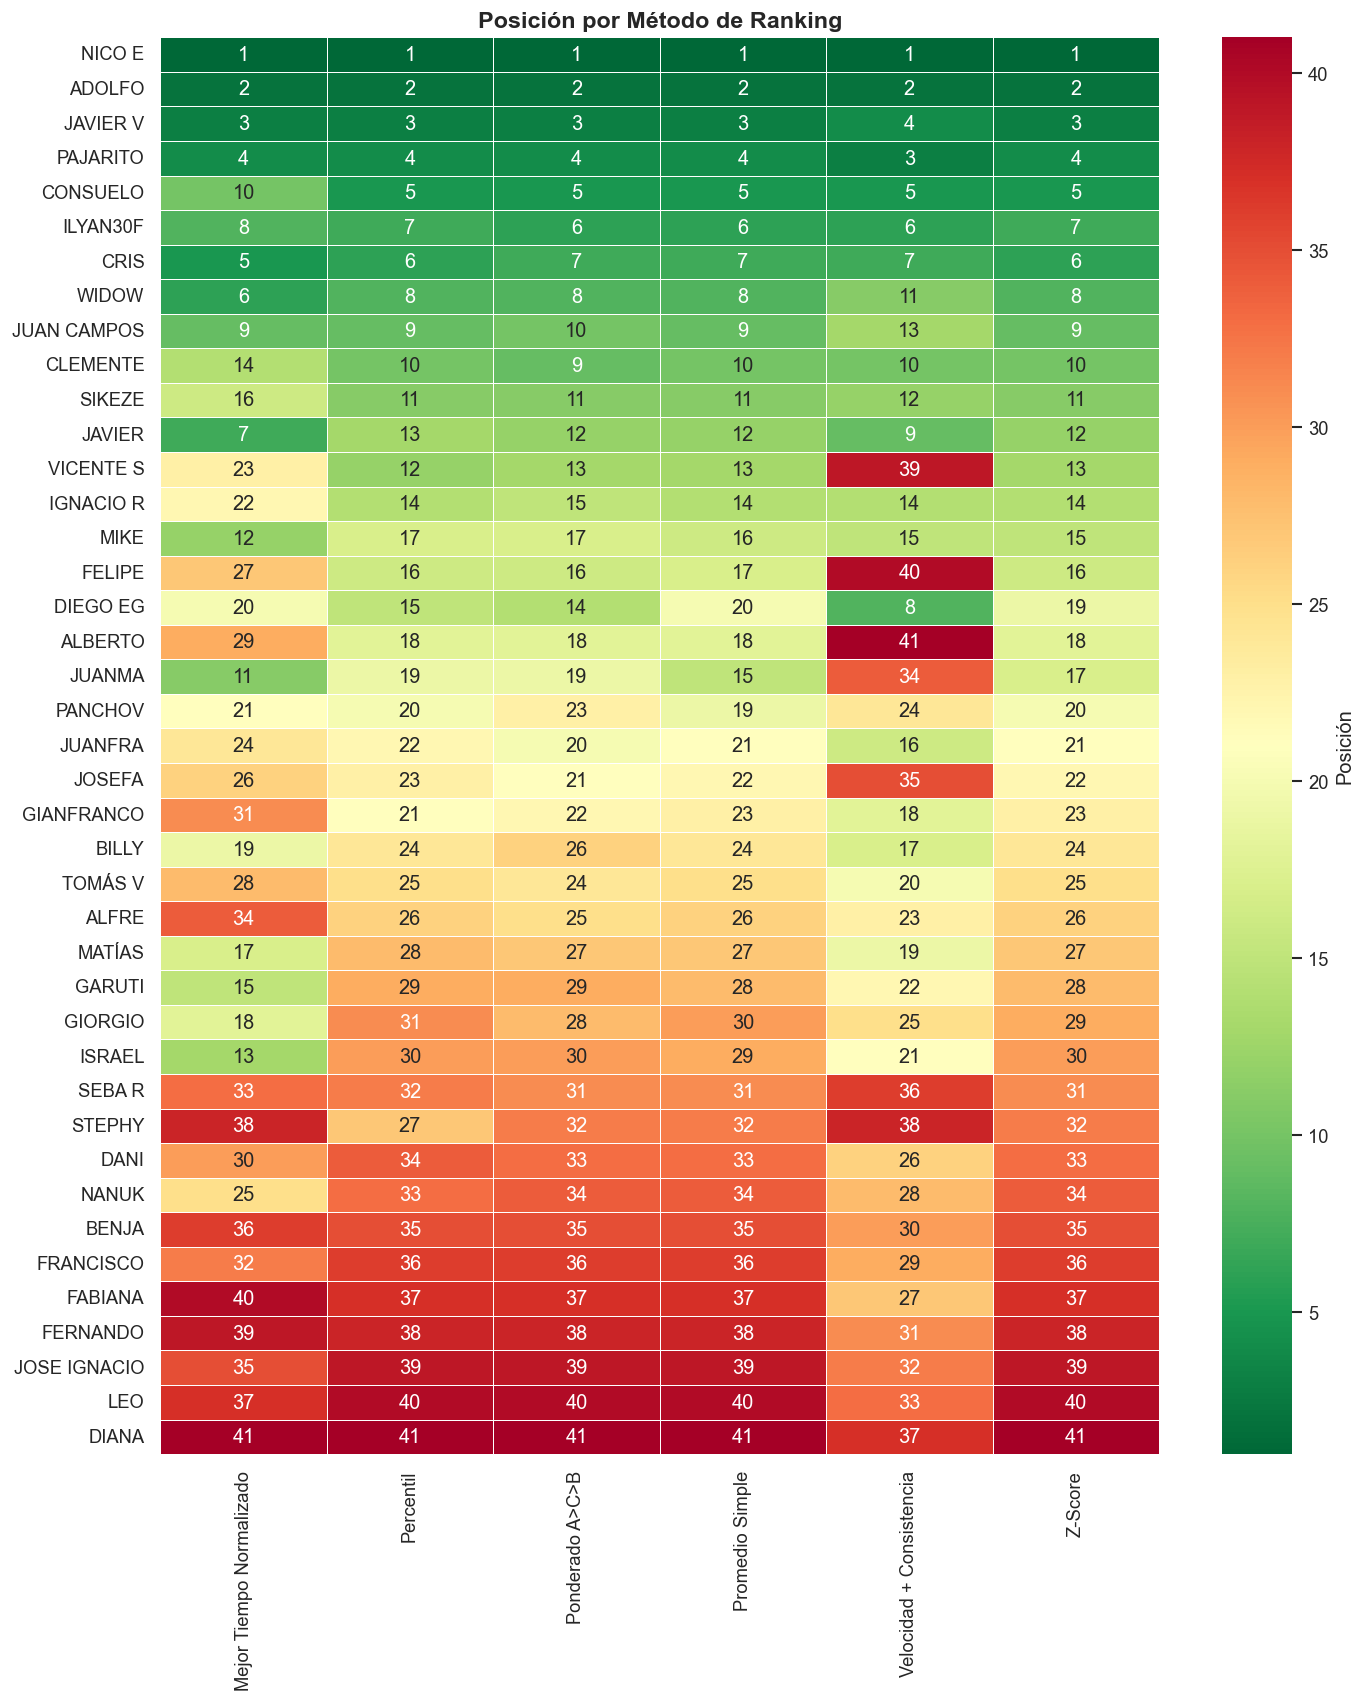

In [59]:
# Heatmap de rankings por método
pivot_ranks = all_rankings.pivot_table(index='Pilotos', columns='method', values='place')
# Ordenar por consenso
order = robust['Pilotos'].tolist()
pivot_ranks = pivot_ranks.reindex(order)

fig, ax = plt.subplots(figsize=(12, max(6, len(order) * 0.35)))
sns.heatmap(
    pivot_ranks, annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Posición'}
)
ax.set_title('Posición por Método de Ranking', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 🔟 Performance Index Pro (0–100)

In [62]:
N = len(robust)
robust['Performance_Index'] = 100 * (1 - (robust['final_place'] - 1) / (N - 1))

# Merge con flags de imputación
impute_flags = metrics[['Pilotos', 'imputed_A', 'imputed_B', 'imputed_C', 'total_sessions']]
robust = robust.merge(impute_flags, on='Pilotos', how='left')
robust['any_imputed'] = robust[['imputed_A', 'imputed_B', 'imputed_C']].any(axis=1)

print(robust[['Pilotos', 'final_place', 'Performance_Index', 'median_place', 'std_place', 'total_sessions', 'any_imputed']]
      .rename(columns={'median_place': 'Mediana Rank', 'std_place': 'Variabilidad', 'total_sessions': 'Sesiones'})
      .to_string(index=False))

     Pilotos  final_place  Performance_Index  Mediana Rank  Variabilidad  Sesiones  any_imputed
      NICO E            1              100.0           1.0      0.000000        12        False
      ADOLFO            2               97.5           2.0      0.000000        14        False
    JAVIER V            3               95.0           3.0      0.408248        12        False
    PAJARITO            4               92.5           4.0      0.408248        11        False
    CONSUELO            5               90.0           5.0      2.041241         1         True
    ILYAN30F            6               87.5           6.5      0.816497         7         True
        CRIS            7               85.0           6.5      0.816497         9         True
       WIDOW            8               82.5           8.0      1.602082         3         True
 JUAN CAMPOS            9               80.0           9.0      1.602082         4         True
    CLEMENTE           10               

## 1️⃣1️⃣ Visualizaciones

In [110]:
fig1 = px.bar(
    robust.sort_values('Performance_Index', ascending=True),  # ascending=True para que el mejor quede arriba en barh
    x='Performance_Index', y='Pilotos',
    orientation='h',
    color='any_imputed',
    color_discrete_map={False: '#3498db', True: '#e74c3c'},
    labels={'Performance_Index': 'Performance Index (0–100)', 'any_imputed': 'Imputado'},
    title='🏆 Performance Index Pro — Ranking Final',
    text=robust.sort_values('Performance_Index', ascending=True)['Performance_Index'].round(1),
    category_orders={'Pilotos': robust.sort_values('Performance_Index', ascending=False)['Pilotos'].tolist()}
)
fig1.update_traces(textposition='outside')
fig1.update_layout(height=max(400, len(robust) * 28), xaxis_range=[0, 110])

In [96]:
fig2 = px.imshow(
    pivot_ranks.reindex(robust['Pilotos'].tolist()),
    color_continuous_scale='RdYlGn_r',
    text_auto=True,
    aspect='auto',
    title='Posición por Método de Ranking',
    labels={'color': 'Posición'}
)
fig2.update_traces(textfont_size=11)
fig2.update_layout(height=max(400, len(robust) * 28))
fig2.show()

In [97]:
order_by_median = (
    df_long[df_long['Trazado'] == 'A']
    .groupby('Pilotos')['Tiempo'].median()
    .sort_values().index.tolist()
)

fig3 = px.box(
    df_long[df_long['Trazado'] == 'A'],
    x='Pilotos', y='Tiempo',
    category_orders={'Pilotos': order_by_median},
    color='Pilotos',
    title='Distribución de Tiempos — Trazado A',
    points='outliers'
)
fig3.update_layout(showlegend=False, xaxis_tickangle=-40, height=500)
fig3.show()

In [113]:
order_by_median = (
    df_long[df_long['Trazado'] == 'C']
    .groupby('Pilotos')['Tiempo'].median()
    .sort_values().index.tolist()
)

fig10 = px.box(
    df_long[df_long['Trazado'] == 'C'],
    x='Pilotos', y='Tiempo',
    category_orders={'Pilotos': order_by_median},
    color='Pilotos',
    title='Distribución de Tiempos — Trazado C',
    points='outliers'
)
fig10.update_layout(showlegend=False, xaxis_tickangle=-40, height=500)
fig10.show()

In [98]:
fig4 = px.box(
    df_long,
    x='Trazado', y='Tiempo',
    color='Trazado',
    title='Distribución de Tiempos por Trazado',
    points='outliers'
)
fig4.update_layout(height=450)
fig4.show()

In [99]:
top5 = robust['Pilotos'].head(5).tolist()
df_top = df_long[df_long['Pilotos'].isin(top5)].copy()
df_top['Fecha_dt'] = pd.to_datetime(df_top['Fecha'], dayfirst=True, errors='coerce')
df_top = df_top.dropna(subset=['Fecha_dt'])
evol = df_top.groupby(['Pilotos', 'Fecha_dt'])['Tiempo'].median().reset_index()

fig5 = px.line(
    evol, x='Fecha_dt', y='Tiempo', color='Pilotos',
    markers=True,
    title='Evolución Temporal — Top 5 Pilotos (mediana por fecha)',
    labels={'Fecha_dt': 'Fecha', 'Tiempo': 'Tiempo (s)'}
)
fig5.update_layout(height=450)
fig5.show()

In [100]:
scatter_df = metrics[['Pilotos', 'overall_median', 'std_within_track', 'total_sessions']].dropna()
scatter_df = scatter_df.merge(robust[['Pilotos', 'Performance_Index']], on='Pilotos', how='left')

fig6 = px.scatter(
    scatter_df,
    x='overall_median', y='std_within_track',
    size='total_sessions', color='Performance_Index',
    color_continuous_scale='RdYlGn',
    hover_name='Pilotos',
    text='Pilotos',
    title='Velocidad vs Consistencia (tamaño = sesiones)',
    labels={
        'overall_median': 'Mediana Global (s) ← más rápido',
        'std_within_track': 'Std por Trazado (s) ← más consistente'
    }
)
fig6.update_traces(textposition='top center', textfont_size=9)
fig6.update_layout(height=550)
fig6.show()

In [116]:
top10 = robust['Pilotos'].head(20).tolist()
trazados = [t for t in ['A', 'B', 'C'] if f'median_{t}' in metrics.columns]

radar_df = metrics[metrics['Pilotos'].isin(top10)].copy()

def normalize_inverted(series):
    """Menor valor → score más alto (para tiempos y std)"""
    return 1 - (series - series.min()) / (series.max() - series.min())

def normalize(series):
    """Mayor valor → score más alto (para sesiones)"""
    return (series - series.min()) / (series.max() - series.min())

for t in trazados:
    radar_df[f'score_{t}'] = normalize_inverted(metrics[f'median_{t}']).reindex(radar_df.index)

radar_df['score_consistencia'] = normalize_inverted(metrics['std_within_track']).reindex(radar_df.index)
radar_df['score_sesiones']     = normalize(metrics['total_sessions']).reindex(radar_df.index)

categories = [f'Trazado {t}' for t in trazados] + ['Consistencia', 'Sesiones']

fig7 = go.Figure()
for _, row in radar_df.iterrows():
    values = [row[f'score_{t}'] for t in trazados]
    values += [row['score_consistencia'], row['score_sesiones']]
    values += [values[0]]  # cerrar

    fig7.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=row['Pilotos'],
        opacity=0.6
    ))

fig7.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Radar de Performance — Top 20 Pilotos',
    height=550
)
fig7.show()

In [102]:
sessions_long = by_trazado[['Pilotos', 'Trazado', 'sessions']].copy()
order_pilotos = robust['Pilotos'].tolist()

fig8 = px.bar(
    sessions_long,
    x='Pilotos', y='sessions', color='Trazado',
    category_orders={'Pilotos': order_pilotos},
    title='Sesiones por Piloto y Trazado',
    labels={'sessions': 'Sesiones', 'Pilotos': ''},
    color_discrete_map={'A': '#3498db', 'B': '#2ecc71', 'C': '#e67e22'}
)
fig8.update_layout(xaxis_tickangle=-40, height=450)
fig8.show()

In [103]:
var_df = robust.sort_values('std_place', ascending=False).copy()
var_df['color'] = var_df['std_place'] > var_df['std_place'].median()

fig9 = px.bar(
    var_df,
    x='std_place', y='Pilotos',
    orientation='h',
    color='color',
    color_discrete_map={True: '#e67e22', False: '#27ae60'},
    title='Sensibilidad del Ranking — Variabilidad entre Métodos',
    labels={'std_place': 'Desviación Estándar de Posición', 'color': 'Alta variabilidad'}
)
fig9.add_vline(x=var_df['std_place'].median(), line_dash='dash', line_color='gray')
fig9.update_layout(height=max(400, len(var_df) * 28), showlegend=False)
fig9.show()

In [ ]:
descripciones = {
    '🏆 Performance Index': 'Ranking final consolidado a partir de 6 metodologías independientes. Score de 0 a 100 donde 100 es el mejor piloto. En rojo los pilotos que tienen al menos un trazado imputado por regresión.',
    '🗂️ Heatmap Rankings': 'Posición de cada piloto según cada método de ranking. Verde = buena posición, Rojo = mala posición. Permite ver qué tan estable es el ranking de cada piloto independientemente de la metodología.',
    '📦 Boxplot Trazado A': 'Distribución de tiempos en el Trazado A (trazado original). Cada caja muestra la mediana, el rango intercuartil y los outliers. Ordenado de más rápido a más lento.',
    '📦 Boxplot Trazado C': 'Distribución de tiempos en el Trazado C (trazado nuevo). Cada caja muestra la mediana, el rango intercuartil y los outliers. Ordenado de más rápido a más lento.',
    '📊 Boxplot por Trazado': 'Comparación de la distribución de tiempos entre trazados. Trazado A = original, Trazado B = lluvia, Trazado C = nuevo trazado.',
    '📈 Evolución Temporal': 'Evolución de la mediana de tiempos por fecha para los 5 mejores pilotos. Permite ver tendencias de mejora o deterioro a lo largo del campeonato.',
    '⚡ Velocidad vs Consistencia': 'Cada punto es un piloto. Eje X = mediana global (más a la izquierda = más rápido). Eje Y = desviación estándar dentro de cada trazado (más abajo = más consistente). El tamaño indica cantidad de sesiones y el color el Performance Index.',
    '🎯 Radar Top 10': 'Perfil de rendimiento de los 6 mejores pilotos en 5 dimensiones, todas normalizadas de 0 a 1 donde 1 es siempre mejor. Trazado A = original, Trazado B = lluvia, Trazado C = nuevo trazado. Consistencia = inverso del std dentro de cada trazado.',
    '📅 Sesiones por Trazado': 'Cantidad de sesiones disputadas por cada piloto, desglosadas por trazado. Permite identificar pilotos con poca participación cuyo ranking puede ser menos representativo.',
    '🎲 Variabilidad Ranking': 'Desviación estándar de la posición de cada piloto entre los 6 métodos de ranking. Alta variabilidad = el resultado depende mucho de la metodología elegida. Naranja = sobre la mediana de variabilidad.',
}

with open('karting_analysis.html', 'w', encoding='utf-8') as f:
    f.write('''<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<style>
  body {
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
    background: #0f1117;
    color: #ffffff;
    padding: 20px;
    max-width: 1400px;
    margin: 0 auto;
  }
  h1 {
    font-size: clamp(1.4em, 4vw, 2.2em);
    font-weight: 700;
    border-bottom: 2px solid #3498db;
    padding-bottom: 12px;
    margin-bottom: 30px;
  }
  h2 {
    font-size: clamp(0.9em, 2.5vw, 1.3em);
    font-weight: 600;
    color: #a0aec0;
    margin-top: 50px;
    margin-bottom: 6px;
    text-transform: uppercase;
    letter-spacing: 0.05em;
  }
  .descripcion {
    font-size: 0.88em;
    color: #718096;
    margin-bottom: 10px;
    line-height: 1.5;
    max-width: 900px;
  }
  .plot-container {
    touch-action: pan-y;
    margin-bottom: 10px;
  }
  @media (max-width: 600px) {
    body { padding: 12px; }
  }
</style>
</head>
<body>
<h1>🏁 Karting Championship Analysis</h1>
<p style="color:#718096; font-size:0.9em; margin-bottom:40px;">
  <strong style="color:#a0aec0">Trazado A</strong> — Trazado original &nbsp;|&nbsp;
  <strong style="color:#a0aec0">Trazado B</strong> — Condición lluvia &nbsp;|&nbsp;
  <strong style="color:#a0aec0">Trazado C</strong> — Nuevo trazado
</p>
''')

    for nombre, fig in [
            ('🏆 Performance Index', fig1),
            ('🗂️ Heatmap Rankings', fig2),
            ('📦 Boxplot Trazado A', fig3),
            ('📦 Boxplot Trazado C', fig10),  # ← agregar tu nueva variable acá
            ('📊 Boxplot por Trazado', fig4),
            ('📈 Evolución Temporal', fig5),
            ('⚡ Velocidad vs Consistencia', fig6),
            ('🎯 Radar Top 10', fig7),
            ('📅 Sesiones por Trazado', fig8),
            ('🎲 Variabilidad Ranking', fig9),
        ]:
        desc = descripciones.get(nombre, '')
        f.write(f'<h2>{nombre}</h2>\n')
        f.write(f'<p class="descripcion">{desc}</p>\n')
        f.write('<div class="plot-container">\n')
        f.write(fig.to_html(
            full_html=False,
            include_plotlyjs='cdn',
            config={'scrollZoom': False, 'displayModeBar': False}
        ) + '\n')
        f.write('</div>\n')

    f.write('</body></html>')

print('✅ Dashboard exportado')

✅ Dashboard exportado


In [125]:
# ── Fig 1: Performance Index ──────────────────────────────────────
fig1 = px.bar(
    robust.sort_values('Performance_Index', ascending=True),
    x='Performance_Index', y='Pilotos',
    orientation='h',
    color='any_imputed',
    color_discrete_map={False: '#3498db', True: '#e74c3c'},
    labels={'Performance_Index': 'Performance Index (0–100)', 'any_imputed': 'Imputado'},
    title='🏆 Performance Index Pro — Ranking Final',
    text=robust.sort_values('Performance_Index', ascending=True)['Performance_Index'].round(1),
    category_orders={'Pilotos': robust.sort_values('Performance_Index', ascending=False)['Pilotos'].tolist()}
)
fig1.update_traces(textposition='outside')
fig1.update_layout(height=max(400, len(robust) * 28), xaxis_range=[0, 110])

# ── Fig 2: Heatmap Rankings ───────────────────────────────────────
fig2 = px.imshow(
    pivot_ranks.reindex(robust.sort_values('Performance_Index', ascending=False)['Pilotos'].tolist()),
    color_continuous_scale='RdYlGn_r',
    text_auto=True,
    title='Posición por Método de Ranking',
    labels={'color': 'Posición'}
)
fig2.update_traces(textfont_size=11)
fig2.update_layout(height=max(400, len(robust) * 28))

# ── Fig 3: Boxplot Trazado A ──────────────────────────────────────
order_a = (
    df_long[df_long['Trazado'] == 'A']
    .groupby('Pilotos')['Tiempo'].median()
    .sort_values().index.tolist()
)
fig3 = px.box(
    df_long[df_long['Trazado'] == 'A'],
    x='Pilotos', y='Tiempo',
    category_orders={'Pilotos': order_a},
    color='Pilotos',
    title='Distribución de Tiempos — Trazado A (Original)',
    points='outliers'
)
fig3.update_layout(showlegend=False, xaxis_tickangle=-40, height=500)

# ── Fig 10: Boxplot Trazado C ─────────────────────────────────────
order_c = (
    df_long[df_long['Trazado'] == 'C']
    .groupby('Pilotos')['Tiempo'].median()
    .sort_values().index.tolist()
)
fig10 = px.box(
    df_long[df_long['Trazado'] == 'C'],
    x='Pilotos', y='Tiempo',
    category_orders={'Pilotos': order_c},
    color='Pilotos',
    title='Distribución de Tiempos — Trazado C (Nuevo)',
    points='outliers'
)
fig10.update_layout(showlegend=False, xaxis_tickangle=-40, height=500)

# ── Fig 4: Boxplot por Trazado ────────────────────────────────────
fig4 = px.box(
    df_long,
    x='Trazado', y='Tiempo',
    color='Trazado',
    title='Distribución de Tiempos por Trazado',
    points='outliers'
)
fig4.update_layout(height=450)

# ── Fig 5: Evolución Temporal Top 5 ──────────────────────────────
top5 = robust.sort_values('Performance_Index', ascending=False)['Pilotos'].head(5).tolist()
df_top = df_long[df_long['Pilotos'].isin(top5)].copy()
df_top['Fecha_dt'] = pd.to_datetime(df_top['Fecha'], dayfirst=True, errors='coerce')
df_top = df_top.dropna(subset=['Fecha_dt'])
evol = df_top.groupby(['Pilotos', 'Fecha_dt'])['Tiempo'].median().reset_index()

fig5 = px.line(
    evol, x='Fecha_dt', y='Tiempo', color='Pilotos',
    markers=True,
    title='Evolución Temporal — Top 5 Pilotos (mediana por fecha)',
    labels={'Fecha_dt': 'Fecha', 'Tiempo': 'Tiempo (s)'}
)
fig5.update_layout(height=450)

# ── Fig 6: Velocidad vs Consistencia ─────────────────────────────
scatter_df = metrics[['Pilotos', 'overall_median', 'std_within_track', 'total_sessions']].dropna()
scatter_df = scatter_df.merge(robust[['Pilotos', 'Performance_Index']], on='Pilotos', how='left')

fig6 = px.scatter(
    scatter_df,
    x='overall_median', y='std_within_track',
    size='total_sessions', color='Performance_Index',
    color_continuous_scale='RdYlGn',
    hover_name='Pilotos',
    text='Pilotos',
    title='Velocidad vs Consistencia (tamaño = sesiones)',
    labels={
        'overall_median': 'Mediana Global (s) ← más rápido',
        'std_within_track': 'Std por Trazado (s) ← más consistente'
    }
)
fig6.update_traces(textposition='top center', textfont_size=9)
fig6.update_layout(height=550)

# ── Fig 7: Radar Top 6 ────────────────────────────────────────────
top6 = robust.sort_values('Performance_Index', ascending=False)['Pilotos'].head(10).tolist()
trazados = [t for t in ['A', 'B', 'C'] if f'median_{t}' in metrics.columns]

radar_df = metrics[metrics['Pilotos'].isin(top6)].copy()

def normalize_inverted(series):
    return 1 - (series - series.min()) / (series.max() - series.min())

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

for t in trazados:
    radar_df[f'score_{t}'] = normalize_inverted(metrics[f'median_{t}']).reindex(radar_df.index)

radar_df['score_consistencia'] = normalize_inverted(metrics['std_within_track']).reindex(radar_df.index)
radar_df['score_sesiones']     = normalize(metrics['total_sessions']).reindex(radar_df.index)

categories = [f'Trazado {t}' for t in trazados] + ['Consistencia', 'Sesiones']

fig7 = go.Figure()
for _, row in radar_df.iterrows():
    values = [row[f'score_{t}'] for t in trazados]
    values += [row['score_consistencia'], row['score_sesiones']]
    values += [values[0]]
    fig7.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=row['Pilotos'],
        opacity=0.6
    ))
fig7.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Radar de Performance — Top 10 Pilotos',
    height=550
)

# ── Fig 8: Sesiones por Trazado ───────────────────────────────────
order_pilotos = robust.sort_values('Performance_Index', ascending=False)['Pilotos'].tolist()
fig8 = px.bar(
    by_trazado,
    x='Pilotos', y='sessions', color='Trazado',
    category_orders={'Pilotos': order_pilotos},
    title='Sesiones por Piloto y Trazado',
    labels={'sessions': 'Sesiones', 'Pilotos': ''},
    color_discrete_map={'A': '#3498db', 'B': '#2ecc71', 'C': '#e67e22'}
)
fig8.update_layout(xaxis_tickangle=-40, height=450)

# ── Fig 9: Variabilidad Ranking ───────────────────────────────────
var_df = robust.sort_values('std_place', ascending=False).copy()
var_df['alta_variabilidad'] = var_df['std_place'] > var_df['std_place'].median()

fig9 = px.bar(
    var_df,
    x='std_place', y='Pilotos',
    orientation='h',
    color='alta_variabilidad',
    color_discrete_map={True: '#e67e22', False: '#27ae60'},
    title='Sensibilidad del Ranking — Variabilidad entre Métodos',
    labels={'std_place': 'Desviación Estándar de Posición', 'alta_variabilidad': 'Alta variabilidad'}
)
fig9.add_vline(x=var_df['std_place'].median(), line_dash='dash', line_color='gray')
fig9.update_layout(height=max(400, len(var_df) * 28), showlegend=False)

# ── Export HTML ───────────────────────────────────────────────────
descripciones = {
    '🏆 Performance Index': 'Ranking final consolidado a partir de 6 metodologías independientes. Score de 0 a 100 donde 100 es el mejor piloto. En rojo los pilotos que tienen al menos un trazado imputado por regresión.',
    '🗂️ Heatmap Rankings': 'Posición de cada piloto según cada método de ranking. Verde = buena posición, Rojo = mala posición. Permite ver qué tan estable es el ranking de cada piloto independientemente de la metodología.',
    '📦 Boxplot Trazado A': 'Distribución de tiempos en el Trazado A (trazado original). Cada caja muestra la mediana, el rango intercuartil y los outliers. Ordenado de más rápido a más lento.',
    '📦 Boxplot Trazado C': 'Distribución de tiempos en el Trazado C (trazado nuevo). Cada caja muestra la mediana, el rango intercuartil y los outliers. Ordenado de más rápido a más lento.',
    '📊 Boxplot por Trazado': 'Comparación de la distribución de tiempos entre trazados. Trazado A = original, Trazado B = lluvia, Trazado C = nuevo trazado.',
    '📈 Evolución Temporal': 'Evolución de la mediana de tiempos por fecha para los 5 mejores pilotos. Permite ver tendencias de mejora o deterioro a lo largo del campeonato.',
    '⚡ Velocidad vs Consistencia': 'Cada punto es un piloto. Eje X = mediana global (más a la izquierda = más rápido). Eje Y = desviación estándar dentro de cada trazado (más abajo = más consistente). El tamaño indica cantidad de sesiones y el color el Performance Index.',
    '🎯 Radar Top 10': 'Perfil de rendimiento de los 10 mejores pilotos en 5 dimensiones, todas normalizadas de 0 a 1 donde 1 es siempre mejor. Trazado A = original, Trazado B = lluvia, Trazado C = nuevo trazado. Consistencia = inverso del std dentro de cada trazado.',
    '📅 Sesiones por Trazado': 'Cantidad de sesiones disputadas por cada piloto, desglosadas por trazado. Permite identificar pilotos con poca participación cuyo ranking puede ser menos representativo.',
    '🎲 Variabilidad Ranking': 'Desviación estándar de la posición de cada piloto entre los 6 métodos de ranking. Alta variabilidad = el resultado depende mucho de la metodología elegida. Naranja = sobre la mediana de variabilidad.',
}

with open('karting_analysis.html', 'w', encoding='utf-8') as f:
    f.write('''<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<style>
  body {
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
    background: #0f1117;
    color: #ffffff;
    padding: 20px;
    max-width: 1400px;
    margin: 0 auto;
  }
  h1 {
    font-size: clamp(1.4em, 4vw, 2.2em);
    font-weight: 700;
    border-bottom: 2px solid #3498db;
    padding-bottom: 12px;
    margin-bottom: 30px;
  }
  h2 {
    font-size: clamp(0.9em, 2.5vw, 1.3em);
    font-weight: 600;
    color: #a0aec0;
    margin-top: 50px;
    margin-bottom: 6px;
    text-transform: uppercase;
    letter-spacing: 0.05em;
  }
  .descripcion {
    font-size: 0.88em;
    color: #718096;
    margin-bottom: 10px;
    line-height: 1.5;
    max-width: 900px;
  }
  .plot-container {
    touch-action: pan-y;
    margin-bottom: 10px;
  }
  @media (max-width: 600px) {
    body { padding: 12px; }
  }
</style>
</head>
<body>
<h1>🏁 Karting Championship Analysis</h1>
<p style="color:#718096; font-size:0.9em; margin-bottom:40px;">
  <strong style="color:#a0aec0">Trazado A</strong> — Trazado original &nbsp;|&nbsp;
  <strong style="color:#a0aec0">Trazado B</strong> — Condición lluvia &nbsp;|&nbsp;
  <strong style="color:#a0aec0">Trazado C</strong> — Nuevo trazado
</p>
''')

    for nombre, fig in [
        ('🏆 Performance Index', fig1),
        ('🗂️ Heatmap Rankings', fig2),
        ('📦 Boxplot Trazado A', fig3),
        ('📦 Boxplot Trazado C', fig10),
        ('📊 Boxplot por Trazado', fig4),
        ('📈 Evolución Temporal', fig5),
        ('⚡ Velocidad vs Consistencia', fig6),
        ('🎯 Radar Top 10', fig7),
        ('📅 Sesiones por Trazado', fig8),
        ('🎲 Variabilidad Ranking', fig9),
    ]:
        desc = descripciones.get(nombre, '')
        f.write(f'<h2>{nombre}</h2>\n')
        f.write(f'<p class="descripcion">{desc}</p>\n')
        f.write('<div class="plot-container">\n')
        f.write(fig.to_html(
            full_html=False,
            include_plotlyjs='cdn',
            config={'scrollZoom': False}
        ) + '\n')
        f.write('</div>\n')

    f.write('</body></html>')

print('✅ Dashboard exportado')

✅ Dashboard exportado


## 1️⃣2️⃣ Análisis de Sensibilidad

In [69]:
variability = all_rankings.groupby('Pilotos')['place'].agg(['median','std','count']).reset_index()
variability.columns = ['Pilotos', 'Mediana_Pos', 'Std_Pos', 'N_Métodos']
variability = variability.sort_values('Mediana_Pos')

print('📊 Análisis de Sensibilidad (variabilidad entre métodos):')
print(variability.to_string(index=False))
print(f"\nPilotos con alta variabilidad (std > {variability['Std_Pos'].median():.1f}):")
high_var = variability[variability['Std_Pos'] > variability['Std_Pos'].median()]
print(high_var[['Pilotos', 'Mediana_Pos', 'Std_Pos']].to_string(index=False))

📊 Análisis de Sensibilidad (variabilidad entre métodos):
     Pilotos  Mediana_Pos   Std_Pos  N_Métodos
      NICO E          1.0  0.000000          6
      ADOLFO          2.0  0.000000          6
    JAVIER V          3.0  0.408248          6
    PAJARITO          4.0  0.408248          6
    CONSUELO          5.0  2.041241          6
    ILYAN30F          6.5  0.816497          6
        CRIS          6.5  0.816497          6
       WIDOW          8.0  1.602082          6
 JUAN CAMPOS          9.0  1.602082          6
    CLEMENTE         10.0  1.760682          6
      SIKEZE         11.0  2.000000          6
      JAVIER         12.0  2.316607          6
   VICENTE S         13.0 10.703582          6
   IGNACIO R         14.0  3.209361          6
        MIKE         15.5  1.861899          6
      FELIPE         16.5  9.818350          6
    DIEGO EG         17.0  4.690416          6
     ALBERTO         18.0  9.563821          6
      JUANMA         18.0  7.859177          6
   

## 1️⃣3️⃣ Resultado Final

In [70]:
final = robust[['final_place', 'Pilotos', 'Performance_Index', 'median_place', 'std_place', 'total_sessions', 'any_imputed']].copy()
final.columns = ['#', 'Piloto', 'Performance Index', 'Mediana Rank', 'Variabilidad', 'Sesiones', 'Tiene Imputaciones']
final['Performance Index'] = final['Performance Index'].round(1)
final['Mediana Rank']      = final['Mediana Rank'].round(1)
final['Variabilidad']      = final['Variabilidad'].round(2)

print('🏁 RANKING OFICIAL FINAL')
print('=' * 80)
print(final.to_string(index=False))

🏁 RANKING OFICIAL FINAL
 #       Piloto  Performance Index  Mediana Rank  Variabilidad  Sesiones  Tiene Imputaciones
 1       NICO E              100.0           1.0          0.00        12               False
 2       ADOLFO               97.5           2.0          0.00        14               False
 3     JAVIER V               95.0           3.0          0.41        12               False
 4     PAJARITO               92.5           4.0          0.41        11               False
 5     CONSUELO               90.0           5.0          2.04         1                True
 6     ILYAN30F               87.5           6.5          0.82         7                True
 7         CRIS               85.0           6.5          0.82         9                True
 8        WIDOW               82.5           8.0          1.60         3                True
 9  JUAN CAMPOS               80.0           9.0          1.60         4                True
10     CLEMENTE               77.5          10

In [ ]:
data = worksheet.get_all_values()
raw = pd.DataFrame(data)

# =========================
# 2️⃣ Extraer estructura real
# =========================
semanas_row = raw.iloc[0]     # fila 0: S51, S52...
fechas_row = raw.iloc[1]      # fila 1: 04/01/2026, 11/01/2026...
headers = raw.iloc[2]         # fila 2: N, Pilotos, Mejor Tiempo...

df = raw.iloc[3:].copy()
df.columns = headers.str.strip()

# =========================
# 3️⃣ Renombrar columnas carrera con índice único
# =========================
fechas_filled = pd.Series(fechas_row.values).replace("", pd.NA).ffill()

new_cols = []
for i, col in enumerate(df.columns):
    if "Carrera" in str(col):
        new_cols.append(f"{col}__idx{i}")
    else:
        new_cols.append(col)
df.columns = new_cols

race_cols = [col for col in df.columns if "Carrera" in col]
print("Meta columnas:", df.columns[:4].tolist())
print("Cantidad columnas carrera:", len(race_cols))

# =========================
# 4️⃣ Construir mapeo columna → fecha
# =========================
col_to_fecha = {}
for col in race_cols:
    i = int(col.split("__idx")[1])
    col_to_fecha[col] = fechas_filled.iloc[i]

print("Muestra mapeo:", list(col_to_fecha.items())[:6])

# =========================
# 5️⃣ Melt
# =========================
df_long = df.melt(
    id_vars=["Pilotos"],
    value_vars=race_cols,
    var_name="Columna",
    value_name="Tiempo"
)
df_long["Tiempo"] = pd.to_numeric(df_long["Tiempo"], errors="coerce")
df_long = df_long.dropna(subset=["Tiempo"])

# =========================
# 6️⃣ Agregar fecha, carrera y trazado
# =========================
df_long["Fecha"] = df_long["Columna"].map(col_to_fecha)
df_long["Carrera"] = df_long["Columna"].apply(lambda x: x.split("__idx")[0])

def asignar_trazado(fecha):
    try:
        fecha = pd.to_datetime(fecha, dayfirst=True)
    except Exception:
        return None
    if fecha == pd.Timestamp("2026-01-25"):
        return "B"
    if fecha < pd.Timestamp("2026-02-22"):
        return "A"
    else:
        return "C"

df_long["Trazado"] = df_long["Fecha"].apply(asignar_trazado)

print(df_long.head(10))

Meta columnas: ['', 'N', 'Pilotos', 'Mejor Tiempo']
Cantidad columnas carrera: 104
Muestra mapeo: [('Carrera 1__idx5', '04/01/2026'), ('Carrera 2__idx6', '04/01/2026'), ('Carrera 1__idx7', '11/01/2026'), ('Carrera 2__idx8', '11/01/2026'), ('Carrera 1__idx9', '18/01/2026'), ('Carrera 2__idx10', '18/01/2026')]
     Pilotos          Columna  Tiempo       Fecha    Carrera Trazado
0     NICO E  Carrera 1__idx5  39.136  04/01/2026  Carrera 1       A
1     ADOLFO  Carrera 1__idx5  38.841  04/01/2026  Carrera 1       A
3   PAJARITO  Carrera 1__idx5  39.525  04/01/2026  Carrera 1       A
6   JAVIER V  Carrera 1__idx5  39.492  04/01/2026  Carrera 1       A
9   DIEGO EG  Carrera 1__idx5  39.927  04/01/2026  Carrera 1       A
28      DANI  Carrera 1__idx5  41.987  04/01/2026  Carrera 1       A
41            Carrera 1__idx5   5.000  04/01/2026  Carrera 1       A
42    NICO E  Carrera 2__idx6  39.530  04/01/2026  Carrera 2       A
43    ADOLFO  Carrera 2__idx6  39.323  04/01/2026  Carrera 2       A


---
## 📋 Notas Metodológicas

**Ranking Consenso Robusto:** Se generan 6 rankings independientes con distintos supuestos (promedio, ponderado, z-score, percentil, mejor tiempo, velocidad+consistencia). El consenso se basa en la **mediana** de posiciones, lo que reduce la influencia de outliers y sesgos de metodología individual.

**Imputación Bidireccional:** Los pilotos sin datos en un trazado reciben un tiempo estimado via regresión lineal usando los trazados disponibles. Se intenta A→B, B→A, A→C, C→A, B→C, C→B, en ese orden. Los pilotos imputados son marcados explícitamente.

**Performance Index Pro:** Escala 0–100 basada en posición final del consenso robusto. El primero recibe 100, el último 0, distribución lineal.

**Variabilidad:** El std de posición entre métodos indica qué tan robusto es el ranking de cada piloto. Alta variabilidad = resultado más sensible a la metodología elegida.